Boundary shape : (600, 2)
Interior shape : (1353, 2)


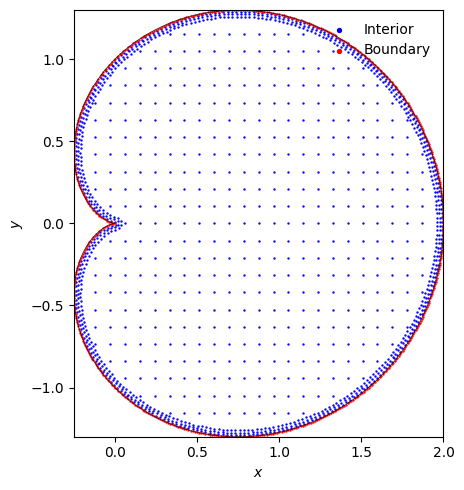

In [1]:
# ==========================================================
# Cardioid Point Generation
# ==========================================================
# Generates:
#   1. Boundary points
#   2. Boundary-layer interior points
#   3. Core interior points
#
# All points are saved in NumPy format
# inside the data/ directory.
# ==========================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from shapely.geometry import (
    Polygon,
    Point,
    LineString,
    MultiPolygon
)


# ==========================================================
# 1. Cardioid Geometry
# ==========================================================
def cardioid_domain(N=2000):
    """
    Create cardioid polygon:
        r = 1 + cos(theta)
    """

    theta = np.linspace(
        0,
        2 * np.pi,
        N,
        endpoint=False
    )

    r = 1 + np.cos(theta)

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    coords = np.vstack([x, y]).T

    return Polygon(coords)


# ==========================================================
# 2. Uniform Boundary Points
# ==========================================================
def boundary_points(domain, Nb=500):

    boundary_line = LineString(
        domain.exterior.coords
    )

    s = np.linspace(
        0,
        boundary_line.length,
        Nb,
        endpoint=False
    )

    pts = np.array([
        [
            boundary_line.interpolate(si).x,
            boundary_line.interpolate(si).y
        ]
        for si in s
    ])

    return pts


# ==========================================================
# 3. Boundary-Layer Interior Points
# ==========================================================
def boundary_layer_points(
    domain,
    n_layers=2,
    base_spacing=0.01,
    growth=1.5,
    points_per_layer=300
):

    pts = []

    d = base_spacing

    inner_polygon = domain

    for _ in range(n_layers):

        candidate = inner_polygon.buffer(-d)

        if candidate.is_empty:
            break

        # ==================================================
        # If multiple disconnected regions appear,
        # keep only the largest one.
        # ==================================================
        if isinstance(candidate, MultiPolygon):

            candidate = max(
                candidate.geoms,
                key=lambda g: g.area
            )

        ring = LineString(candidate.exterior.coords)

        L = ring.length

        s_vals = np.linspace(
            0,
            L,
            points_per_layer,
            endpoint=False
        )

        for s in s_vals:

            p = ring.interpolate(s)

            pts.append([p.x, p.y])

        inner_polygon = candidate

        d *= growth

    return np.array(pts), inner_polygon


# ==========================================================
# 4. Interior Fill Points
# ==========================================================
def interior_fill(domain, N=20):

    xmin, ymin, xmax, ymax = domain.bounds

    xs = np.linspace(xmin, xmax, N)
    ys = np.linspace(ymin, ymax, N)

    pts = []

    for x in xs:

        for y in ys:

            if domain.contains(Point(x, y)):

                pts.append([x, y])

    return np.array(pts)


# ==========================================================
# 5. Generate Domain Points
# ==========================================================
domain = cardioid_domain()

boundary_pts = boundary_points(
    domain,
    Nb=600
)

boundary_layer_pts, core_domain = boundary_layer_points(
    domain,
    n_layers=3,
    base_spacing=0.01,
    growth=1.3,
    points_per_layer=300
)

interior_fill_pts = interior_fill(
    core_domain,
    N=25
)

interior_pts = np.vstack([
    boundary_layer_pts,
    interior_fill_pts
])


# ==========================================================
# 6. Remove Duplicate Points
# ==========================================================
interior_pts = np.unique(
    interior_pts,
    axis=0
)


# ==========================================================
# 7. Save Points in data/ Directory
# ==========================================================
os.makedirs(
    "data",
    exist_ok=True
)

np.save(
    "data/cardioid_boundary_points.npy",
    boundary_pts
)

np.save(
    "data/cardioid_interior_points.npy",
    interior_pts
)

print("Boundary shape :", boundary_pts.shape)
print("Interior shape :", interior_pts.shape)
# ==========================================================
# 8. Plot Domain Points
# ==========================================================
fig, ax = plt.subplots(figsize=(6, 5))


# ==========================================================
# Boundary Coordinates
# ==========================================================
xi_b = boundary_pts[:, 0]
yi_b = boundary_pts[:, 1]


# ==========================================================
# Compute Axis Limits
# ==========================================================
x_all = np.concatenate([
    interior_pts[:, 0],
    boundary_pts[:, 0]
])

y_all = np.concatenate([
    interior_pts[:, 1],
    boundary_pts[:, 1]
])

xmin, xmax = x_all.min(), x_all.max()
ymin, ymax = y_all.min(), y_all.max()


# ==========================================================
# Boundary Curve
# ==========================================================
ax.plot(
    xi_b,
    yi_b,
    color="black",
    linewidth=0.6,
    alpha=0.7,
    zorder=3
)


# ==========================================================
# Interior Points
# ==========================================================
ax.scatter(
    interior_pts[:, 0],
    interior_pts[:, 1],
    s=0.5,
    color="blue",
    label="Interior"
)


# ==========================================================
# Boundary Points
# ==========================================================
ax.scatter(
    boundary_pts[:, 0],
    boundary_pts[:, 1],
    s=0.5,
    color="red",
    label="Boundary"
)


# ==========================================================
# Axis Settings
# ==========================================================
ax.set_aspect(
    'equal',
    adjustable='box'
)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)


# ==========================================================
# Legend
# ==========================================================
ax.legend(
    loc="upper right",
    frameon=False,
    markerscale=4
)


# ==========================================================
# Save Figure
# ==========================================================
plt.tight_layout()

plt.savefig(
    "fig2_domain.pdf",dpi=300,
    bbox_inches="tight",
    pad_inches=0.15
)


plt.show()

plt.close(fig)